# Replication of the paper - Virtue of Complexity everywhere

In [ ]:
pip install autograd

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pymanopt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import itertools

import numpy as np
from matplotlib import pyplot as plt

import autograd.numpy as anp
from pymanopt import Problem
from pymanopt.manifolds import Grassmann
from pymanopt.function import autograd as pymanopt_autograd
from pymanopt.optimizers import ConjugateGradient, SteepestDescent, TrustRegions

## Equity Factors prediction

### Outline of the strategy

Similar to VOC, but we do it for each of the 159 equity factors that we have i.e, a timing strategy for each of them separately

### Things to Note

We start with an IPCA strategy exploting the cross-sectional information, instead of just macro predictors like in RFFs case

### Download the data

In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
SAVE_DIR = DATA_DIR
print(f"ROOT_DIR : {ROOT_DIR}")
print(f"DATA_DIR : {DATA_DIR}")

def save_csv(df, filename):
    path = SAVE_DIR / filename
    df.to_csv(path)
    print(f"  Saved → {path}  ({df.shape[0]} rows x {df.shape[1]} cols)")


# ── 1. FF5 ────────────────────────────────────────────────────────────────────

def get_ff5_factors():
    print("\n[1/3] Downloading FF5 factors...")
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = next(f for f in z.namelist() if f.lower().endswith('.csv'))
    with z.open(fname) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = next(i for i, l in enumerate(lines) if l.strip()[:6].isdigit())
    end = start
    for i in range(start, len(lines)):
        if lines[i].strip() == '' and i > start + 10:
            end = i
            break
    df = pd.read_csv(
        io.StringIO('\n'.join(lines[start:end])),
        header=None,
        names=['date', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
    )
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date')
    df = df.apply(pd.to_numeric, errors='coerce').dropna() / 100
    df.columns = ['ff_' + c for c in df.columns]
    print(f"  FF5: {df.index[0].date()} → {df.index[-1].date()}, {len(df)} months")
    return df


def get_momentum_factor():
    print("\n[1b] Downloading Momentum factor...")
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    fname = next(f for f in z.namelist() if f.lower().endswith('.csv'))
    with z.open(fname) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = next(i for i, l in enumerate(lines) if l.strip()[:6].isdigit())
    end = start
    for i in range(start, len(lines)):
        if lines[i].strip() == '' and i > start + 10:
            end = i
            break
    df = pd.read_csv(
        io.StringIO('\n'.join(lines[start:end])),
        header=None,
        names=['date', 'Mom']
    )
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date')
    df['Mom'] = pd.to_numeric(df['Mom'], errors='coerce') / 100
    df = df.dropna()
    df.columns = ['ff_' + c for c in df.columns]
    print(f"  Mom: {df.index[0].date()} → {df.index[-1].date()}, {len(df)} months")
    return df


def get_welch_goyal():
    print("\n[2/3] Loading Welch-Goyal predictors...")
    fpath = list(DATA_DIR.glob('PredictorData*'))[0]
    print(f"  Found: {fpath.name}")

    if str(fpath).endswith(('.xlsx', '.xls')):
        df = pd.read_excel(fpath, sheet_name='Monthly')
    else:
        df = pd.read_csv(fpath)

    df = df.rename(columns={'yyyymm': 'date'})
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m')
    df = df.set_index('date').sort_index()

    # Force every column to numeric — Index is str in your file
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"  Index sample: {df['Index'].dropna().head(3).values}")

    df_wg = pd.DataFrame(index=df.index)
    df_wg['wg_dp']       = np.log(df['D12'])  - np.log(df['Index'])
    df_wg['wg_dy']       = np.log(df['D12'])  - np.log(df['Index'].shift(1))
    df_wg['wg_ep']       = np.log(df['E12'])  - np.log(df['Index'])
    df_wg['wg_de']       = np.log(df['D12'])  - np.log(df['E12'])
    df_wg['wg_bm']       = df['b/m']
    df_wg['wg_ntis']     = df['ntis']
    df_wg['wg_tbl']      = df['tbl']
    df_wg['wg_lty']      = df['lty']
    df_wg['wg_ltr']      = df['ltr']
    df_wg['wg_infl']     = df['infl']
    df_wg['wg_svar']     = df['svar']
    df_wg['wg_dfy']      = df['BAA']   - df['AAA']
    df_wg['wg_dfr']      = df['corpr'] - df['ltr']
    df_wg['wg_tms']      = df['lty']   - df['tbl']
    df_wg['wg_mkt_lag1'] = df['Index'].pct_change().shift(1)

    df_wg = df_wg.apply(pd.to_numeric, errors='coerce').dropna(how='all')
    print(f"  WG: {df_wg.index[0].date()} → {df_wg.index[-1].date()}, "
          f"{len(df_wg)} months, {df_wg.shape[1]} variables")
    print(f"  Non-null counts:\n{df_wg.notnull().sum()}")
    return df_wg


def load_jkp():
    print("\n[3/3] Loading JKP factors...")
    fpath = DATA_DIR / 'jkp.csv'
    df = pd.read_csv(fpath)

    df['date'] = pd.to_datetime(df['date'])

    # Normalize dates to month-start to match FF and WG
    df['date'] = df['date'].values.astype('datetime64[M]')

    df_wide = df.pivot_table(index='date', columns='name', values='ret', aggfunc='first')
    df_wide.index.name = 'date'
    df_wide = df_wide.sort_index()
    df_wide.columns = ['jkp_' + c for c in df_wide.columns]

    print(f"  JKP: {df_wide.index[0].date()} → {df_wide.index[-1].date()}, "
          f"{len(df_wide)} months, {df_wide.shape[1]} factors")
    print(f"  Factors: {[c.replace('jkp_','') for c in df_wide.columns]}")
    return df_wide


# ── PREPROCESSING ─────────────────────────────────────────────────────────────

def standardize_returns(ret: pd.Series, window: int = 12) -> pd.Series:
    vol = ret.rolling(window).apply(lambda x: np.sqrt(np.mean(x**2)))
    return (ret / vol.shift(1)).replace([np.inf, -np.inf], np.nan)

def standardize_signals(X: pd.DataFrame, min_obs: int = 37) -> pd.DataFrame:
    result = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
    for col in X.columns:
        expanding_std = X[col].expanding(min_periods=min_obs).std()
        result[col] = (X[col] / expanding_std.shift(1)).clip(-5, 5)
    return result

def build_momentum_signals(factor_ret: pd.Series) -> pd.DataFrame:
    X = pd.DataFrame(index=factor_ret.index)
    X['ret_lag1'] = factor_ret.shift(1)
    X['ret_lag2_12'] = factor_ret.shift(2).rolling(11).mean()
    return X


# ── MAIN ──────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    print("=" * 65)
    print("  Kelly-Malamud-Zhou (2022) — Equity Factor Data Download")
    print("=" * 65)

    ff5  = get_ff5_factors()
    mom  = get_momentum_factor()
    ff_all = ff5.join(mom, how='outer')
    save_csv(ff_all, 'ff_factors.csv')

    wg   = get_welch_goyal()
    save_csv(wg, 'welch_goyal_predictors.csv')

    jkp  = load_jkp()
    save_csv(jkp, 'jkp_factors_usa_monthly.csv')

    # ── Merge ─────────────────────────────────────────────────────────────────
    print("\n── Merging all datasets ──────────────────────────────────────")
    merged = ff_all.join(wg,  how='outer') \
                   .join(jkp, how='outer') \
                   .sort_index()

    print(f"  Full shape  : {merged.shape}")
    print(f"  Date range  : {merged.index[0].date()} → {merged.index[-1].date()}")
    print(f"  ff_ cols    : {len([c for c in merged.columns if c.startswith('ff_')])}")
    print(f"  wg_ cols    : {len([c for c in merged.columns if c.startswith('wg_')])}")
    print(f"  jkp_ cols   : {len([c for c in merged.columns if c.startswith('jkp_')])}")

    common = merged.dropna(how='any').index
    if len(common):
        print(f"  Full overlap: {common[0].date()} → {common[-1].date()} ({len(common)} months)")

    save_csv(merged, 'all_data_merged.csv')
    print(f"\n✓ All files saved to: {SAVE_DIR}")

ROOT_DIR : /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation
DATA_DIR : /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/data
  Kelly-Malamud-Zhou (2022) — Equity Factor Data Download

[1/3] Downloading FF5 factors...
  FF5: 1963-07-01 → 2026-01-01, 751 months

[1b] Downloading Momentum factor...
  Mom: 1927-01-01 → 2026-01-01, 1189 months
  Saved → /Users/chaithanyapakala/Desktop/researchAndrew/TheVirtueOfComplexity_PaperReplication_Experimentation/data/ff_factors.csv  (1189 rows x 7 cols)

[2/3] Loading Welch-Goyal predictors...
  Found: PredictorData2021 - Monthly.csv
  Index sample: [4.44 4.5  4.61]
  WG: 1871-01-01 → 2021-12-01, 1812 months, 15 variables
  Non-null counts:
wg_dp          1551
wg_dy          1551
wg_ep          1551
wg_de          1812
wg_bm          1210
wg_ntis        1141
wg_tbl         1224
wg_lty         1236
wg_ltr         1152
wg_infl        1307
wg_svar 

In [ ]:
print(wg.shape, ff5.shape, mom.shape, jkp.shape)

(1812, 15) (751, 6) (1189, 1) (1188, 13)


In [ ]:
merged_trunc = merged[(merged.index.year > 1980)& (merged.index.year < 2021)] # truncate it

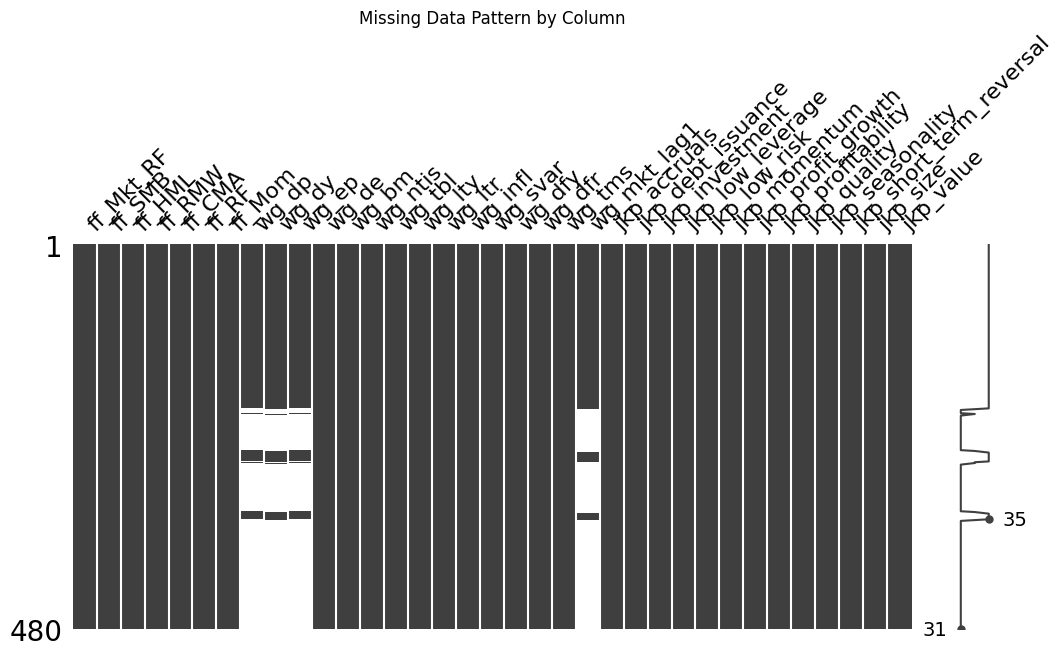

In [ ]:
# get missing data c

# Visualize missing data patterns
msno.matrix(merged_trunc, figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.show()

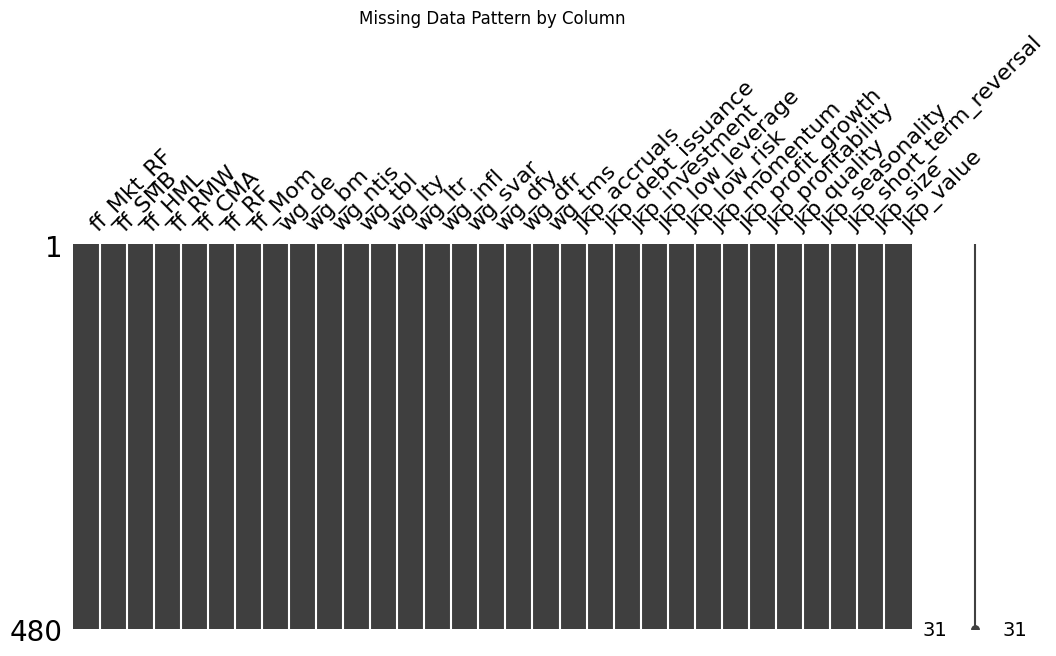

In [ ]:
#Lets get rid of the 4 predictso with a lot of nans
feats = [col for col in merged_trunc.columns if col not in ['wg_dp', 'wg_dy', 'wg_ep', 'wg_mkt_lag1']]


# get missing data c

# Visualize missing data patterns
msno.matrix(merged_trunc[feats], figsize=(12, 5))
plt.title("Missing Data Pattern by Column")
plt.show()

In [ ]:
# Lets work with just 31 features for now, we will extend to all the features later
df = merged_trunc[feats]

In [ ]:
df.head(-5)

,ff_Mkt_RF,ff_SMB,ff_HML,ff_RMW,ff_CMA,ff_RF,ff_Mom,wg_de,wg_bm,wg_ntis,...,jkp_low_leverage,jkp_low_risk,jkp_momentum,jkp_profit_growth,jkp_profitability,jkp_quality,jkp_seasonality,jkp_short_term_reversal,jkp_size,jkp_value
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,-0.0506,0.0330,0.0674,-0.0338,0.0427,0.0104,-0.0782,-0.866016,0.907239,0.028695,...,-0.019523,0.048566,-0.058776,-0.023648,-0.038931,-0.021366,0.000211,-0.009292,0.049486,0.054983
1981-02-01,0.0061,-0.0065,0.0097,0.0026,0.0206,0.0107,-0.0135,-0.854143,0.881816,0.030009,...,-0.004663,0.014236,-0.003338,-0.007910,-0.005200,0.003603,-0.002775,-0.009965,-0.004252,0.018210
1981-03-01,0.0366,0.0285,0.0061,-0.0227,-0.0056,0.0121,0.0082,-0.842281,0.924921,0.027939,...,-0.003233,0.000398,-0.015186,-0.006294,-0.011882,0.000108,0.005139,0.015530,0.013850,0.012002
1981-04-01,-0.0216,0.0472,0.0228,0.0081,0.0154,0.0108,-0.0108,-0.846234,0.930594,0.027352,...,0.005796,0.018726,0.010985,-0.005683,-0.003592,0.012281,0.000908,0.001136,0.032095,0.010561
1981-05-01,0.0013,0.0236,-0.0043,0.0047,-0.0178,0.0115,0.0356,-0.850149,0.936224,0.028845,...,0.009812,-0.012021,0.024549,0.007401,0.004527,0.004939,-0.001201,-0.017712,0.006182,-0.014697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012,0.0821,-0.669101,0.306097,-0.007700,...,0.057200,0.064948,0.056106,0.019596,0.032428,0.061268,-0.023236,-0.002540,-0.056952,-0.085380
2020-04-01,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000,-0.0548,-0.618286,0.275563,-0.010538,...,0.034473,-0.089420,-0.045639,-0.003612,-0.029667,0.003712,0.016294,0.030095,0.028638,-0.003624
2020-05-01,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001,0.0016,-0.564814,0.264301,-0.014967,...,0.041227,-0.028549,0.025328,0.002350,-0.029066,0.018798,-0.000238,-0.003323,-0.013895,-0.061341


## IPCA explanation and strategy layout

In [46]:
df.head(-5)

,ff_Mkt_RF,ff_SMB,ff_HML,ff_RMW,ff_CMA,ff_RF,ff_Mom,wg_de,wg_bm,wg_ntis,...,jkp_low_leverage,jkp_low_risk,jkp_momentum,jkp_profit_growth,jkp_profitability,jkp_quality,jkp_seasonality,jkp_short_term_reversal,jkp_size,jkp_value
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,-0.0506,0.0330,0.0674,-0.0338,0.0427,0.0104,-0.0782,-0.866016,0.907239,0.028695,...,-0.019523,0.048566,-0.058776,-0.023648,-0.038931,-0.021366,0.000211,-0.009292,0.049486,0.054983
1981-02-01,0.0061,-0.0065,0.0097,0.0026,0.0206,0.0107,-0.0135,-0.854143,0.881816,0.030009,...,-0.004663,0.014236,-0.003338,-0.007910,-0.005200,0.003603,-0.002775,-0.009965,-0.004252,0.018210
1981-03-01,0.0366,0.0285,0.0061,-0.0227,-0.0056,0.0121,0.0082,-0.842281,0.924921,0.027939,...,-0.003233,0.000398,-0.015186,-0.006294,-0.011882,0.000108,0.005139,0.015530,0.013850,0.012002
1981-04-01,-0.0216,0.0472,0.0228,0.0081,0.0154,0.0108,-0.0108,-0.846234,0.930594,0.027352,...,0.005796,0.018726,0.010985,-0.005683,-0.003592,0.012281,0.000908,0.001136,0.032095,0.010561
1981-05-01,0.0013,0.0236,-0.0043,0.0047,-0.0178,0.0115,0.0356,-0.850149,0.936224,0.028845,...,0.009812,-0.012021,0.024549,0.007401,0.004527,0.004939,-0.001201,-0.017712,0.006182,-0.014697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012,0.0821,-0.669101,0.306097,-0.007700,...,0.057200,0.064948,0.056106,0.019596,0.032428,0.061268,-0.023236,-0.002540,-0.056952,-0.085380
2020-04-01,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000,-0.0548,-0.618286,0.275563,-0.010538,...,0.034473,-0.089420,-0.045639,-0.003612,-0.029667,0.003712,0.016294,0.030095,0.028638,-0.003624
2020-05-01,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001,0.0016,-0.564814,0.264301,-0.014967,...,0.041227,-0.028549,0.025328,0.002350,-0.029066,0.018798,-0.000238,-0.003323,-0.013895,-0.061341


In [47]:
df.columns

Index(['ff_Mkt_RF', 'ff_SMB', 'ff_HML', 'ff_RMW', 'ff_CMA', 'ff_RF', 'ff_Mom',
       'wg_de', 'wg_bm', 'wg_ntis', 'wg_tbl', 'wg_lty', 'wg_ltr', 'wg_infl',
       'wg_svar', 'wg_dfy', 'wg_dfr', 'wg_tms', 'jkp_accruals',
       'jkp_debt_issuance', 'jkp_investment', 'jkp_low_leverage',
       'jkp_low_risk', 'jkp_momentum', 'jkp_profit_growth',
       'jkp_profitability', 'jkp_quality', 'jkp_seasonality',
       'jkp_short_term_reversal', 'jkp_size', 'jkp_value'],
      dtype='str')

In [48]:
# We want to predic tthe excess return of the market factor, using the Grasmanninan approach in 'IPCA_Gass_estimation.py' in src/pycache, lest create charateristics(Zt) for all of the features, and then we will use the IPCA approach to predict the excess return of the market factor.
def create_characteristics(df):
    # Create lagged momentum and vol features for each factor
    for col in df.columns:
        df[f'{col}_lag2_12'] = df[col].shift(2).rolling(11).mean()
        # create volatility features
        df[f'{col}_vol_12'] = df[col].shift(1).rolling(12).std
        # create other charactere


### Build inputs to be able to use IPCA_Grass_estimator

In [49]:


def build_ipca_inputs(
    df: pd.DataFrame,
    factor_prefix: str = "jkp_",
    macro_prefixes: tuple = ("wg_", "ff_"),
    include_intercept: bool = True,
    clip_signals: float = 5.0,
    impute: str = "zero",   # "zero" or "drop"
):
    """
    Build data = [rets, Z] for GrassmannManifoldIPCAEstimator.
    rets: (T, N)  where N = number of equity factors (assets)
    Z:    (T, N, m)
    """

    # 1) Equity factors as cross-section "assets"
    R = df[[c for c in df.columns if c.startswith(factor_prefix)]].copy()
    R = R.sort_index()

    # 2) Per-factor lagged characteristics (no look-ahead)
    lag1 = R.shift(1)
    mom_2_12 = R.shift(2).rolling(11).mean()
    vol_12 = R.shift(1).rolling(12).std()  # fixed: std()

    # Time-series standardization (asset-by-asset)
    def _std_ts(X):
        s = X.expanding(min_periods=37).std()
        return (X / s.shift(1)).clip(-clip_signals, clip_signals)

    lag1_s = _std_ts(lag1)
    mom_s = _std_ts(mom_2_12)
    vol_s = _std_ts(vol_12)

    # 3) Optional macro predictors, replicated across assets at each t
    macro_cols = [c for c in df.columns if any(c.startswith(p) for p in macro_prefixes)]
    M = df[macro_cols].copy().sort_index() if macro_cols else pd.DataFrame(index=R.index)
    M = M.shift(1)  # ensure no look-ahead
    M_s = _std_ts(M) if not M.empty else M
    

    # 4) Build aligned panel
    # Target returns are contemporaneous R_t; predictors are lagged by construction above.
    aligned = pd.concat([R, lag1_s, mom_s, vol_s, M_s], axis=1)

    if impute == "drop":
        aligned = aligned.dropna()
        R = aligned[R.columns]
        lag1_s = aligned[lag1_s.columns]
        mom_s = aligned[mom_s.columns]
        vol_s = aligned[vol_s.columns]
        M_s = aligned[M_s.columns] if not M_s.empty else M_s
    elif impute == "zero":
        R = R.fillna(0.0)
        lag1_s = lag1_s.fillna(0.0)
        mom_s = mom_s.fillna(0.0)
        vol_s = vol_s.fillna(0.0)
        if not M_s.empty:
            M_s = M_s.fillna(0.0)
    else:
        raise ValueError("impute must be 'zero' or 'drop'")

    # 5) Tensor assembly
    T, N = R.shape
    chars = []

    if include_intercept:
        chars.append(np.ones((T, N), dtype=float))  # (T,N,1)

    chars.extend([
        lag1_s.to_numpy(dtype=float),
        mom_s.to_numpy(dtype=float),
        vol_s.to_numpy(dtype=float),
    ])

    if not M_s.empty:
        M_np = M_s.to_numpy(dtype=float)  # (T, q)
        for j in range(M_np.shape[1]):
            chars.append(np.repeat(M_np[:, [j]], N, axis=1))  # (T,N)

    Z = np.stack(chars, axis=2)                 # (T, N, m)
    rets = R.to_numpy(dtype=float)              # (T, N)

    meta = {
        "dates": R.index,
        "asset_names": list(R.columns),
        "num_assets": N,
        "num_char": Z.shape[2],
        "num_periods": T,
    }
    return [rets, Z], meta


# Example usage
data_ipca, meta = build_ipca_inputs(
    merged_trunc,
    factor_prefix="jkp_",
    macro_prefixes=("wg_", "ff_"),
    include_intercept=True,
    impute="zero",
)

rets, Z = data_ipca

print("rets shape:", rets.shape)  # (T, N)
print("Z shape   :", Z.shape)     # (T, N, m)
print(meta)

# ...existing code...


# Drop early burn-in periods to avoid unstable early expanding-standardization rows
burn_in = 48  # try 36/48/60
if burn_in >= rets.shape[0]:
    raise ValueError(f"burn_in={burn_in} is too large for T={rets.shape[0]}")

rets = rets[burn_in:, :]
Z = Z[burn_in:, :, :]

# keep metadata aligned
meta["dates"] = meta["dates"][burn_in:]
meta["num_periods"] = rets.shape[0]

print(f"After burn-in drop: rets={rets.shape}, Z={Z.shape}, T={meta['num_periods']}")
# ...existing code...

rets shape: (480, 13)
Z shape   : (480, 13, 26)
{'dates': DatetimeIndex(['1981-01-01', '1981-02-01', '1981-03-01', '1981-04-01',
               '1981-05-01', '1981-06-01', '1981-07-01', '1981-08-01',
               '1981-09-01', '1981-10-01',
               ...
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01',
               '2020-11-01', '2020-12-01'],
              dtype='datetime64[us]', name='date', length=480, freq=None), 'asset_names': ['jkp_accruals', 'jkp_debt_issuance', 'jkp_investment', 'jkp_low_leverage', 'jkp_low_risk', 'jkp_momentum', 'jkp_profit_growth', 'jkp_profitability', 'jkp_quality', 'jkp_seasonality', 'jkp_short_term_reversal', 'jkp_size', 'jkp_value'], 'num_assets': 13, 'num_char': 26, 'num_periods': 480}
After burn-in drop: rets=(432, 13), Z=(432, 13, 26), T=432


### Solve the IPCA/Grassman_manifold optimization problem

In [50]:
# ...existing code...

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.__pycache__.IPCA_Grass_estimator import GrassmannManifoldIPCAEstimator


num_assets = rets.shape[1]
num_fact = 2
num_charact = Z.shape[2]
win_len = rets.shape[0]

est = GrassmannManifoldIPCAEstimator(
    num_assets=num_assets,
    num_fact=num_fact,
    num_charact=num_charact,
    win_len=win_len,
)

Wopt, f_hat, history = est.fit(
    data=[rets, Z],
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=1,
    log_verbosity=1,
)

print("Wopt:", Wopt.shape)   # (m, k)
print("f_hat:", f_hat.shape) # (T, k)

# ...existing code...

Optimizing...
Terminated - max iterations reached after 71.42 seconds.

Wopt: (26, 2)
f_hat: (432, 2)


In [51]:
Wopt_df = pd.DataFrame(Wopt, columns=[f'Factor_{i+1}' for i in range(num_fact)])
Wopt_df['Characteristic'] = [f'Char_{j+1}' for j in range(num_charact)]
Wopt_df = Wopt_df.set_index('Characteristic')
print(Wopt_df)

                Factor_1  Factor_2
Characteristic                    
Char_1         -0.120198  0.132690
Char_2         -0.475529 -0.677554
Char_3          0.254381 -0.306512
Char_4         -0.013280  0.015452
Char_5          0.170204  0.045067
Char_6          0.170920 -0.010734
Char_7         -0.211208  0.001768
Char_8         -0.034364 -0.090967
Char_9          0.110476  0.061662
Char_10        -0.183033  0.107418
Char_11        -0.053600 -0.116705
Char_12         0.125261 -0.068833
Char_13         0.335208 -0.395175
Char_14        -0.042087 -0.127759
Char_15        -0.151946  0.041075
Char_16         0.109164 -0.294036
Char_17         0.415996 -0.004879
Char_18         0.165532  0.016381
Char_19        -0.244035  0.070071
Char_20         0.016865 -0.166262
Char_21        -0.094174  0.223495
Char_22        -0.230389  0.049896
Char_23         0.182335  0.027381
Char_24         0.012561 -0.093397
Char_25        -0.146491  0.063148
Char_26        -0.007373 -0.160085


In [52]:
f_hat_df = pd.DataFrame(f_hat, index=meta['dates'], columns=[f'Factor_{i+1}' for i in range(num_fact)])
print(f_hat_df.head())

            Factor_1  Factor_2
date                          
1985-01-01  0.002087 -0.000984
1985-02-01  0.000864  0.002190
1985-03-01 -0.010006 -0.010207
1985-04-01 -0.008397 -0.009004
1985-05-01 -0.004506 -0.005828


In [53]:
# lets split the factor returns into train and test, and see how well the factors do in-sample vs out-of-sample. We will use the first 80% of the data for training, and the remaining 20% for testing.
# ...existing code...

# Train/test split (time-ordered)
T = rets.shape[0]
split_idx = int(0.8 * T)

rets_train, rets_test = rets[:split_idx], rets[split_idx:]
Z_train, Z_test = Z[:split_idx], Z[split_idx:]
dates_train = meta["dates"][:split_idx]
dates_test = meta["dates"][split_idx:]

print(f"Train: rets={rets_train.shape}, Z={Z_train.shape}")
print(f"Test : rets={rets_test.shape}, Z={Z_test.shape}")

# Fit on TRAIN only
num_assets = rets_train.shape[1]
num_fact = 2
num_charact = Z_train.shape[2]
win_len = rets_train.shape[0]

est = GrassmannManifoldIPCAEstimator(
    num_assets=num_assets,
    num_fact=num_fact,
    num_charact=num_charact,
    win_len=win_len,
)

Wopt, f_hat_train, history = est.fit(
    data=[rets_train, Z_train],
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=1,
    log_verbosity=1,
)

print("Wopt:", Wopt.shape)               # (m, k)
print("f_hat_train:", f_hat_train.shape) # (T_train, k)

def infer_factors_given_W(rets_block, Z_block, W):
    T_block = rets_block.shape[0]
    k = W.shape[1]
    f_block = np.zeros((T_block, k), dtype=float)
    for t in range(T_block):
        Lambda_t = Z_block[t] @ W
        r_t = rets_block[t]
        f_t, *_ = np.linalg.lstsq(Lambda_t, r_t, rcond=None)
        f_block[t] = f_t
    return f_block

def reconstruct_returns(Z_block, f_block, W):
    T_block = Z_block.shape[0]
    N = Z_block.shape[1]
    rhat = np.zeros((T_block, N), dtype=float)
    for t in range(T_block):
        Lambda_t = Z_block[t] @ W
        rhat[t] = Lambda_t @ f_block[t]
    return rhat

# A) Contemporaneous test cross-sectional fit (uses test returns -> NOT forecast)
f_hat_test_cs = infer_factors_given_W(rets_test, Z_test, Wopt)
rhat_test_cs = reconstruct_returns(Z_test, f_hat_test_cs, Wopt)

mse_test_cs = np.mean((rets_test - rhat_test_cs) ** 2)
r2_test_cs = 1.0 - np.sum((rets_test - rhat_test_cs) ** 2) / np.sum((rets_test - rets_test.mean()) ** 2)

print(f"Test contemporaneous CS MSE (not forecast): {mse_test_cs:.6e}")
print(f"Test contemporaneous CS R^2 (not forecast): {r2_test_cs:.4f}")

# B) True OOS forecast (no rets_test used for factor inference)
# simple baseline: use mean train factor return each period
f_mean_train = f_hat_train.mean(axis=0, keepdims=True)                 # (1, k)
f_hat_test_pred = np.repeat(f_mean_train, rets_test.shape[0], axis=0)  # (T_test, k)
rhat_test_pred = reconstruct_returns(Z_test, f_hat_test_pred, Wopt)

mse_oos_forecast = np.mean((rets_test - rhat_test_pred) ** 2)
r2_oos_forecast = 1.0 - np.sum((rets_test - rhat_test_pred) ** 2) / np.sum((rets_test - rets_test.mean()) ** 2)

print(f"True OOS forecast MSE: {mse_oos_forecast:.6e}")
print(f"True OOS forecast R^2: {r2_oos_forecast:.4f}")

# Optional DataFrames
f_hat_train_df = pd.DataFrame(
    f_hat_train, index=dates_train, columns=[f"Factor_{i+1}" for i in range(num_fact)]
)
f_hat_test_cs_df = pd.DataFrame(
    f_hat_test_cs, index=dates_test, columns=[f"Factor_{i+1}" for i in range(num_fact)]
)

print("Train factor returns (estimated):")
print(f_hat_train_df.head())
print("Test factor returns (estimated contemporaneously; not forecast):")
print(f_hat_test_cs_df.head())

# ...existing code...

Train: rets=(345, 13), Z=(345, 13, 26)
Test : rets=(87, 13), Z=(87, 13, 26)
Optimizing...
Terminated - max iterations reached after 56.75 seconds.

Wopt: (26, 2)
f_hat_train: (345, 2)
Test contemporaneous CS MSE (not forecast): 2.002088e-04
Test contemporaneous CS R^2 (not forecast): 0.3009
True OOS forecast MSE: 2.859014e-04
True OOS forecast R^2: 0.0017
Train factor returns (estimated):
            Factor_1  Factor_2
date                          
1985-01-01 -0.034002  0.013102
1985-02-01  0.001830 -0.002773
1985-03-01  0.010562  0.069601
1985-04-01  0.001676  0.010654
1985-05-01  0.005610  0.000331
Test factor returns (estimated contemporaneously; not forecast):
            Factor_1  Factor_2
date                          
2013-10-01  0.000117 -0.021081
2013-11-01  0.021527 -0.002154
2013-12-01  0.006524 -0.007058
2014-01-01  0.017752  0.055443
2014-02-01  0.002068  0.005517


In [54]:
# ...existing code...

def forecast_next_factor(f_train, mode="mean"):
    # f_train: (T_train, k)
    if mode == "mean":
        return f_train.mean(axis=0)
    elif mode == "ar1":
        k = f_train.shape[1]
        out = np.zeros(k)
        for j in range(k):
            y = f_train[1:, j]
            x = f_train[:-1, j]
            X = np.column_stack([np.ones_like(x), x])
            b, *_ = np.linalg.lstsq(X, y, rcond=None)   # y = a + b*x
            out[j] = b[0] + b[1] * f_train[-1, j]
        return out
    else:
        raise ValueError("mode must be 'mean' or 'ar1'")

def walkforward_oos_panel(rets, Z, start_train=120, num_fact=2, factor_model="mean"):
    T, N = rets.shape
    preds = np.full((T, N), np.nan)

    for t in range(start_train, T):
        rets_tr, Z_tr = rets[:t], Z[:t]

        est = GrassmannManifoldIPCAEstimator(
            num_assets=N,
            num_fact=num_fact,
            num_charact=Z.shape[2],
            win_len=rets_tr.shape[0],
        )

        W_t, f_tr, _ = est.fit(
            data=[rets_tr, Z_tr],
            optimizer="ConjugateGradient",
            max_iterations=200,
            verbosity=0,
            log_verbosity=0,
        )

        f_next = forecast_next_factor(f_tr, mode=factor_model)      # uses train only
        Lambda_t = Z[t] @ W_t                                        # uses t characteristics only
        preds[t] = Lambda_t @ f_next                                 # predicts rets[t]

    valid = ~np.isnan(preds).any(axis=1)
    y_true = rets[valid]
    y_pred = preds[valid]

    mse = np.mean((y_true - y_pred) ** 2)

    # OOS R2 vs historical-mean benchmark (computed from training window only each t)
    bench = np.full_like(y_true, np.nan)
    valid_idx = np.where(valid)[0]
    for i, t in enumerate(valid_idx):
        bench[i] = rets[:t].mean(axis=0)

    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_bench = np.sum((y_true - bench) ** 2)
    r2_oos = 1.0 - sse_model / sse_bench

    return preds, {"mse": mse, "r2_oos_vs_hist_mean": r2_oos, "n_oos_periods": valid.sum()}

# run
preds, stats = walkforward_oos_panel(rets, Z, start_train=120, num_fact=2, factor_model="ar1")
print(stats)

# ...existing code...

{'mse': np.float64(0.8828042323003343), 'r2_oos_vs_hist_mean': np.float64(-1152.6177976102565), 'n_oos_periods': np.int64(312)}


# Working with stock level return + characteristics prediction

In [113]:
#These charactereistics dont have much variance in them, making the problem illposed, lets load the return data for these stock from 2020 - 2026 and create our our characteristics using the return data, and then we will use the IPCA approach to predict the return of stocks. We will perform the same for a bigger period later

df_returns = pd.read_excel("df_data_all_stocks_2020_onwards.xlsx")
df_returns.rename(columns={'yyyymm': 'date'}, inplace=True)

In [114]:
df_returns.head()
# lets pivot the table to have permno and date as index, and all the columns as values, and then we will use this data to create our characteristics for the IPCA approach. We will use the return data to create momentum and volatility characteristics for each stock, and then we will use these characteristics to predict the return of stocks using the IPCA approach.

df_returns = df_returns.pivot_table(index=['permno', 'date'], values=[col for col in df_returns.columns if col not in ['permno', 'date']], aggfunc='first')
df_returns.head()

AM       AOP  AbnormalAccruals  Accruals  AccrualsBM  \
permno date                                                                     
10026  2020-01-01  0.297053  0.140903         -0.036085  0.029798         NaN   
       2020-02-01  0.306326  0.140903         -0.036085  0.029798         NaN   
       2020-03-01  0.446013  0.140903          0.005110  0.040243         NaN   
       2020-04-01  0.424841  0.140903          0.005110  0.040243         NaN   
       2020-05-01  0.419556  0.140903          0.005110  0.040243         NaN   

                      AdExp  AnalystRevision  AnalystValue  \
permno date                                                  
10026  2020-01-01  0.001650         1.000000      0.286805   
       2020-02-01  0.001701         0.973129      0.286805   
       2020-03-01  0.002598         0.909270      0.286805   
       2020-04-01  0.002475         0.976139      0.286805   
       2020-05-01  0.002444         0.291111      0.286805   

                   AnnouncementReturn  AssetGrowth  ...      roaq  sfe  \
permno date                                         ...                  
10026  2020-01-01           -0.092029    -0.074704  ...  0.026180  NaN   
       2020-02-01           -0.092029    -0.074704  ...  0.026180  NaN   
       2020-03-01           -0.092029    -0.093696  ...  0.016735  NaN   
       2020-04-01            0.026064    -0.093696  ...  0.016735  NaN   
       2020-05-01            0.026064    -0.093696  ...  0.016735  NaN   

                   sinAlgo     skew1  std_turn      tang  year  zerotrade12M  \
permno date                                                                    
10026  2020-01-01      0.0 -0.050505       NaN  0.710366  2020  8.212433e-08   
       2020-02-01      0.0 -0.031910       NaN  0.710366  2020  8.174433e-08   
       2020-03-01      0.0  0.235420       NaN  0.755241  2020  8.005990e-08   
       2020-04-01      0.0 -0.142723       NaN  0.755241  2020  7.113406e-08   
       2020-05-01      0.0  0.020169       NaN  0.755241  2020  6.537433e-08   

                    zerotrade1M   zerotrade6M  
permno date                                    
10026  2020-01-01  2.013817e-08  1.457501e-07  
       2020-02-01  1.756096e-08  1.399235e-07  
       2020-03-01  2.336111e-08  1.452774e-07  
       2020-04-01  9.570691e-09  1.271560e-07  
       2020-05-01  1.103157e-08  1.143823e-07  

[5 rows x 207 columns]

In [121]:
#lets see how the data looks like for a few more columns, thigs arebeing truncated in.head()

# we need to see more columns i.e, horizontal view
with pd.option_context("display.max_columns", None, "display.width", 50, "display.max_colwidth", None):
    print(df_returns.loc[10104].head(10).to_string())

                  AM  AOP  AbnormalAccruals  Accruals  AccrualsBM     AdExp  AnalystRevision  AnalystValue  AnnouncementReturn  AssetGrowth  BM     BMdec     BPEBM      Beta    BetaFP  BetaLiquidityPS  BetaTailRisk  BidAskSpread  BookLeverage  BrandInvest  CBOperProf        CF  CPVolSpread      Cash  CashProd  ChAssetTurnover      ChEQ  ChForecastAccrual     ChInv   ChInvIA  ChNAnalyst   ChNNCOA     ChNWC     ChTax  ChangeInRecommendation  CitationsRD  CompEquIss  CompositeDebtIssuance  ConsRecomm  ConvDebt  CoskewACX  Coskewness  CredRatDG  CustomerMomentum  DebtIssuance  DelBreadth    DelCOA    DelCOL    DelDRC    DelEqu   DelFINL  DelLTI  DelNetFin  DivInit  DivOmit  DivSeason  DivYieldST     DolVol  DownRecomm       EBM        EP  EarnSupBig  EarningsConsistency  EarningsForecastDisparity  EarningsStreak  EarningsSurprise    EntMult  EquityDuration  ExchSwitch  ExclExp  FEPS  FR  FirmAge  ForecastDispersion  Frontier       GP   GrAdExp   GrLTNOA  GrSaleToGrInv  GrSaleToGrOverhead  

In [152]:
char_feats = [ 'Beta', 'skew1',  'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD']
# lets work with just these 4 features for now, we will extend to all the features later
df_trunc = df_returns[char_feats + ['Price']]
#create a return column from the price, shift the returns by 1 so that there is no look ahead

df_trunc['ret'] = df_trunc.groupby(level=0)['Price'].pct_change()
df_trunc['ret'] = df_trunc['ret'].shift(-1)
df_trunc.dropna(inplace=True)
df_trunc.head()

Beta     skew1     Mom6m  RealizedVol   betaVIX  \
permno date                                                              
10026  2020-01-01  0.212075 -0.050505 -0.002764    -0.025857 -0.003299   
       2020-02-01  0.227315 -0.031910 -0.136068    -0.012975  0.002487   
       2020-03-01  0.553396  0.235420 -0.159782    -0.079814  0.000614   
       2020-04-01  0.517375 -0.142723 -0.360692    -0.046392 -0.000792   
       2020-05-01  0.507410  0.020169 -0.307936    -0.039382 -0.012214   

                    zerotrade6M     VolSD     Price       ret  
permno date                                                    
10026  2020-01-01  1.457501e-07 -0.307756 -5.111023 -0.006014  
       2020-02-01  1.399235e-07 -0.308896 -5.080286 -0.056000  
       2020-03-01  1.452774e-07 -0.500634 -4.795791  0.010141  
       2020-04-01  1.271560e-07 -0.591220 -4.844423  0.002584  
       2020-05-01  1.143823e-07 -0.612271 -4.856940 -0.002415

In [159]:

def run_ipca_grass(
    df_trunc,
    char_feats,
    num_fact=2,
    window_len=12,
    max_nan=0.3,
    max_zero=0.3,
    min_non_nan_frac=0.7,
):
    #Lets perform IPCA_Grass_estimation ont this data, we use char_feats to creae our characterstics, and do a rolling backtest where we fit the model for the last 12 months
    # and then try to predict the return for the next month, and then we will evaluate the performance of the model using mean squared error and R2 score. 
    # Diagnose zeros/NaNs and rebuild panel to reduce singularity issues

    # Build stock-level panel from df_trunc
    df_panel = df_trunc.copy().sort_index()

    # Returns panel (T, N)
    rets_panel = df_panel["ret"].unstack("permno").sort_index()

    # Lagged characteristics panels (T, N) for each feature
    X_list = []
    for col in char_feats:
        x = df_panel[col].unstack("permno").sort_index()
        x = x.shift(1)
        X_list.append(x)

    # Align assets across all panels
    common_assets = rets_panel.columns
    for x in X_list:
        common_assets = common_assets.intersection(x.columns)

    rets_panel = rets_panel[common_assets]
    X_list = [x[common_assets] for x in X_list]

    # Diagnose missing/zeros
    zero_frac_rets = (rets_panel == 0).mean()
    nan_frac_rets = rets_panel.isna().mean()
    #print("rets zero frac (top 5):", zero_frac_rets.sort_values(ascending=False).head())
    #print("rets nan  frac (top 5):", nan_frac_rets.sort_values(ascending=False).head())

    # Drop assets with too many missing/zeros in returns or any characteristic
    good_assets = (nan_frac_rets <= max_nan) & (zero_frac_rets <= max_zero)
    for x in X_list:
        good_assets &= (x.isna().mean() <= max_nan)
        good_assets &= ((x == 0).mean() <= max_zero)

    rets_panel = rets_panel.loc[:, good_assets]
    X_list = [x.loc[:, good_assets] for x in X_list]

    # Drop early rows with heavy NaNs (burn-in)
    min_non_nan = int(min_non_nan_frac * rets_panel.shape[1])
    valid_time = rets_panel.notna().sum(axis=1) >= min_non_nan
    for x in X_list:
        valid_time &= (x.notna().sum(axis=1) >= min_non_nan)

    rets_panel = rets_panel.loc[valid_time]
    X_list = [x.loc[valid_time] for x in X_list]

    # Impute remaining NaNs with cross-sectional mean (avoids zero inflation)
    rets_panel = rets_panel.apply(lambda s: s.fillna(s.mean()), axis=1)
    X_list = [x.apply(lambda s: s.fillna(s.mean()), axis=1) for x in X_list]

    # Standardize characteristics cross-sectionally to avoid collinearity
    X_list = [(x.sub(x.mean(axis=1), axis=0)).div(x.std(axis=1).replace(0, np.nan), axis=0) for x in X_list]
    X_list = [x.fillna(0.0) for x in X_list]

    # Stack into Z: (T, N, m)
    Z = np.stack([x.to_numpy(dtype=float) for x in X_list], axis=2)
    rets_stock = rets_panel.to_numpy(dtype=float)

    # Rolling backtest parameters
    T, N = rets_stock.shape
    preds_stock = np.full_like(rets_stock, np.nan, dtype=float)

    for t in range(window_len, T):
        rets_tr = rets_stock[t - window_len:t]
        Z_tr = Z[t - window_len:t]

        est = GrassmannManifoldIPCAEstimator(
            num_assets=N,
            num_fact=num_fact,
            num_charact=Z.shape[2],
            win_len=rets_tr.shape[0],
        )

        W_t, f_tr, _ = est.fit(
            data=[rets_tr, Z_tr],
            optimizer="ConjugateGradient",
            max_iterations=200,
            verbosity=0,
            log_verbosity=0,
        )

        # Forecast next factor as historical mean in window
        f_next = f_tr.mean(axis=0)
        Lambda_t = Z[t] @ W_t
        preds_stock[t] = Lambda_t @ f_next

    # Evaluate performance on valid rows
    valid = ~np.isnan(preds_stock).any(axis=1)
    y_true = rets_stock[valid]
    y_pred = preds_stock[valid]

    mse_oos = np.mean((y_true - y_pred) ** 2)
    r2_oos = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    # Market-timing Sharpe (annualized for monthly data)
    pos = y_pred / (np.mean(np.abs(y_pred), axis=1, keepdims=True) + 1e-12)
    port_ret = np.mean(pos * y_true, axis=1)
    sharpe = np.mean(port_ret) / (np.std(port_ret, ddof=1) + 1e-12) * np.sqrt(12)

    print(f"OOS MSE: {mse_oos:.6e}")
    print(f"OOS R2 : {r2_oos:.4f}")
    print(f"Market-timing Sharpe (annualized): {sharpe:.3f}")

    return {
        "r2_oos": r2_oos,
        "sharpe": sharpe,
    }


In [157]:


# lets run the function num_iter times to ensure we report the average performance of the model, and not just a lucky run
num_iter = 5
all_results = []
for i in range(num_iter):
    print(f"\nRun {i+1}/{num_iter}")
    res = run_ipca_grass(
        df_trunc=df_trunc,
        char_feats=char_feats,
        num_fact=3,
        window_len=12,
        max_nan=0.3,
        max_zero=0.3,
        min_non_nan_frac=0.7,
    )
    all_results.append(res)
# Aggregate results
avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
avg_sharpe = np.mean([res["sharpe"] for res in all_results])
print(f"\nAverage OOS R2 over {num_iter} runs: {avg_r2_oos:.4f}")
print(f"Average Market-timing Sharpe (annualized) over {num_iter} runs: {avg_sharpe:.3f}")  



Run 1/5
rets zero frac (top 5): permno
10220    0.027778
10026    0.000000
10257    0.000000
10421    0.000000
10397    0.000000
dtype: float64
rets nan  frac (top 5): permno
10239    0.972222
10302    0.972222
10182    0.888889
10333    0.777778
10308    0.777778
dtype: float64
OOS MSE: 9.544895e-04
OOS R2 : -0.1044
Market-timing Sharpe (annualized): -0.079

Run 2/5
rets zero frac (top 5): permno
10220    0.027778
10026    0.000000
10257    0.000000
10421    0.000000
10397    0.000000
dtype: float64
rets nan  frac (top 5): permno
10239    0.972222
10302    0.972222
10182    0.888889
10333    0.777778
10308    0.777778
dtype: float64
OOS MSE: 9.459626e-04
OOS R2 : -0.0946
Market-timing Sharpe (annualized): -0.123

Run 3/5
rets zero frac (top 5): permno
10220    0.027778
10026    0.000000
10257    0.000000
10421    0.000000
10397    0.000000
dtype: float64
rets nan  frac (top 5): permno
10239    0.972222
10302    0.972222
10182    0.888889
10333    0.777778
10308    0.777778
dtype: flo


Num factors: 1, Run 1/3
OOS MSE: 8.890395e-04
OOS R2 : -0.0287
Market-timing Sharpe (annualized): 0.279

Num factors: 1, Run 2/3
OOS MSE: 8.912859e-04
OOS R2 : -0.0313
Market-timing Sharpe (annualized): 0.091

Num factors: 1, Run 3/3
OOS MSE: 8.856801e-04
OOS R2 : -0.0248
Market-timing Sharpe (annualized): 0.188

Num factors: 1, Average OOS R2: -0.0283, Average Sharpe: 0.186

Num factors: 2, Run 1/3
OOS MSE: 8.827601e-04
OOS R2 : -0.0214
Market-timing Sharpe (annualized): 0.884

Num factors: 2, Run 2/3
OOS MSE: 9.235907e-04
OOS R2 : -0.0687
Market-timing Sharpe (annualized): -0.701

Num factors: 2, Run 3/3
OOS MSE: 9.058045e-04
OOS R2 : -0.0481
Market-timing Sharpe (annualized): -0.035

Num factors: 2, Average OOS R2: -0.0461, Average Sharpe: 0.049

Num factors: 3, Run 1/3
OOS MSE: 9.465168e-04
OOS R2 : -0.0952
Market-timing Sharpe (annualized): 0.052

Num factors: 3, Run 2/3
OOS MSE: 9.477502e-04
OOS R2 : -0.0966
Market-timing Sharpe (annualized): 0.275

Num factors: 3, Run 3/3
OOS M

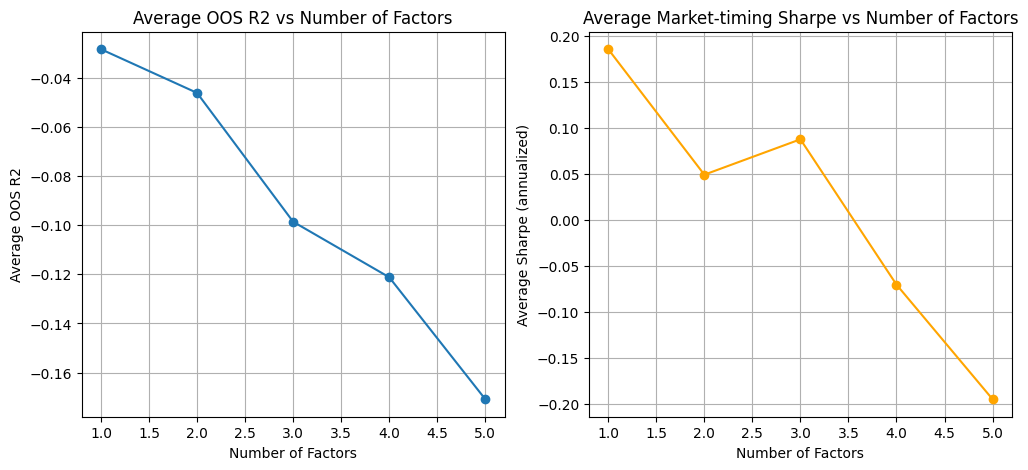

In [161]:
#Lets the same as above but for different num_factors, and see how the performance changes with the number of factors. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 12 months for all runs.
num_factors_list = [1, 2, 3, 4, 5]
num_iter = 3
results_by_factor = {}
for num_fact in num_factors_list:
    # we iterate num_iter times for each num_fact to get an average performance
    all_results = []
    for i in range(num_iter):
        print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
        res = run_ipca_grass(
            df_trunc=df_trunc,
            char_feats=char_feats,
            num_fact=num_fact,
            window_len=12,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
    print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# Lets plot the results
num_factors = list(results_by_factor.keys())
avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(num_factors, avg_r2_oos_values, marker='o')
plt.title("Average OOS R2 vs Number of Factors")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
plt.title("Average Market-timing Sharpe vs Number of Factors")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()


In [ ]:
#lets run the same as above but with window_len = 24, and include more characteristics, and see how the performance changes with the window length and the number of characteristics. We will try with 1, 2, 3, 4, 5 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
char_feats_extended = ['Beta', 'skew1', 'Mom6m', 'RealizedVol', 'betaVIX', 'zerotrade6M', 'VolSD', 'Mom12m', 'Mom1m', 'Vol1m']
window_len = 24

In [175]:
 # dont truncate while printing columns, we want to see all the columns to decide which ones to include as characteristics
print(df_returns.columns.tolist()) # print columns as list for better readability
# lets pick 50 characteristics with least missing data, and not mostly constant values, and then we will use these characteristics to run the IPCA_Grass_estimation and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Diagnose missing/zeros for all columns
nan_frac = df_returns.isna().mean()
zero_frac = (df_returns == 0).mean()
# Filter columns with low missing/zero fractions
good_cols = (nan_frac <= 0.3) & (zero_frac <= 0.3)
good_cols = good_cols[good_cols].index.tolist()
print(f"Number of good columns: {len(good_cols)}")
print("Good columns:", good_cols)
# We will exclude the 'Price' column and the 'ret' column from the characteristics, and we will also exclude the columns that are not in the good_cols list, and then we will
# run the IPCA_Grass_estimation with the remaining columns as characteristics, and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
excluded_cols = ['Price', 'ret']
char_feats_final = [col for col in good_cols if col not in excluded_cols]
print(f"Number of characteristics used: {len(char_feats_final)}")
print("Characteristics used:", char_feats_final)
# create a df to pass to the function
df_trunc_extended = df_returns[char_feats_final + ['Price']]
# create return column
df_trunc_extended['ret'] = df_trunc_extended.groupby(level=0)['Price'].pct_change()
df_trunc_extended['ret'] = df_trunc_extended['ret'].shift(-1)
df_trunc_extended.dropna(inplace=True)

['AM', 'AOP', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'AdExp', 'AnalystRevision', 'AnalystValue', 'AnnouncementReturn', 'AssetGrowth', 'BM', 'BMdec', 'BPEBM', 'Beta', 'BetaFP', 'BetaLiquidityPS', 'BetaTailRisk', 'BidAskSpread', 'BookLeverage', 'BrandInvest', 'CBOperProf', 'CF', 'CPVolSpread', 'Cash', 'CashProd', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNAnalyst', 'ChNNCOA', 'ChNWC', 'ChTax', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'ConvDebt', 'CoskewACX', 'Coskewness', 'CredRatDG', 'CustomerMomentum', 'DebtIssuance', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelDRC', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'DownRecomm', 'EBM', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'EquityDuration', 'ExchSwitch', 'ExclExp', 'FEPS', 'FR', 'FirmAge', 'ForecastDispersion', 'Frontie

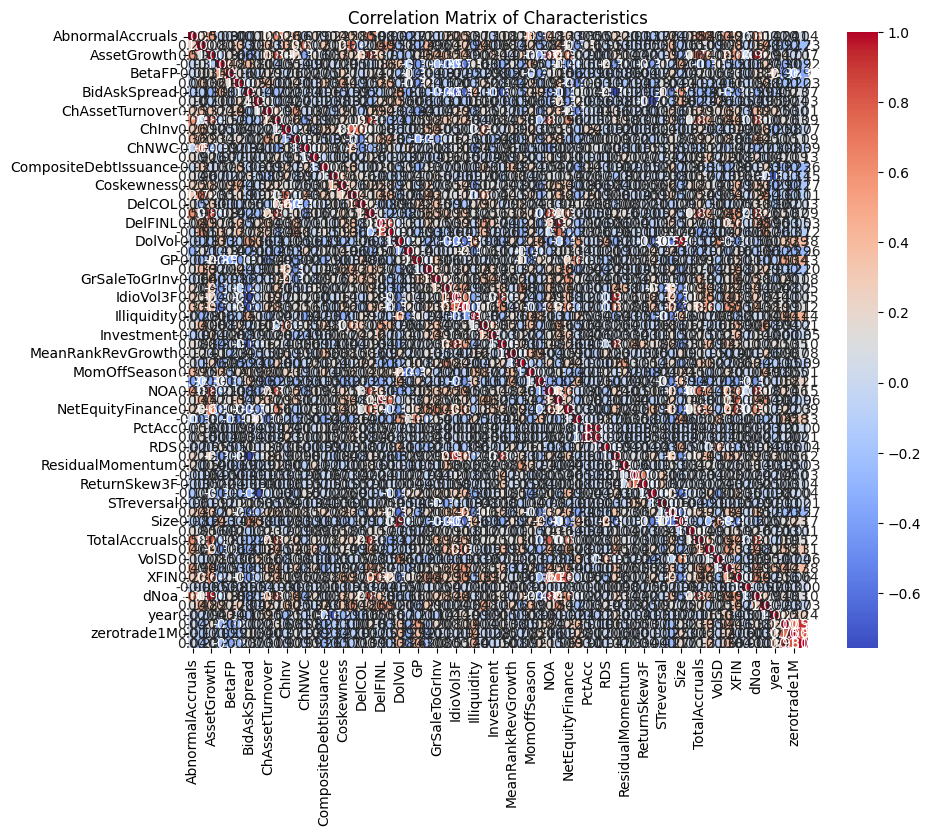

In [178]:
#some characteristics are causing 0 correlation in the IPCA estimation, we will try to identify these characteristics and remove them from the characteristics list, and then we will run the IPCA_Grass_estimation again and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
df_trunc_extended[char_feats_final]
# lets analyise df_trunc_extended[char_feats_final] to identify characteristics with low variance or high correlation with other characteristics, as these can cause issues in the IPCA estimation. We will look at the correlation matrix and the variance of each characteristic, and then we will remove the characteristics that have low variance or high correlation with other characteristics, and then we will run the IPCA_Grass_estimation again and see how the performance changes with the number of factors and the window length. We will try with 2, 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
# Correlation matrix
corr_matrix = df_trunc_extended[char_feats_final].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Characteristics")
plt.show()

Number of characteristics used after reduction: 33
Characteristics used after reduction: ['MaxRet', 'MeanRankRevGrowth', 'Mom12mOffSeason', 'MomOffSeason', 'MomOffSeason06YrPlus', 'NOA', 'NetDebtFinance', 'NetEquityFinance', 'OPLeverage', 'PctAcc', 'PctTotAcc', 'RDS', 'RealizedVol', 'ResidualMomentum', 'ReturnSkew', 'ReturnSkew3F', 'RoE', 'STreversal', 'ShareRepurchase', 'Size', 'Tax', 'TotalAccruals', 'VolMkt', 'VolSD', 'VolumeTrend', 'XFIN', 'betaVIX', 'dNoa', 'hire', 'year', 'zerotrade12M', 'zerotrade1M', 'zerotrade6M']

Num factors: 1, Run 1/3
OOS MSE: 6.666218e-01
OOS R2 : -1171.4043
Market-timing Sharpe (annualized): 0.703

Num factors: 1, Run 2/3
OOS MSE: 4.889270e+00
OOS R2 : -8597.8808
Market-timing Sharpe (annualized): 0.609

Num factors: 1, Run 3/3
OOS MSE: 8.144384e+00
OOS R2 : -14322.7303
Market-timing Sharpe (annualized): 0.348

Num factors: 1, Average OOS R2: -8030.6718, Average Sharpe: 0.553

Num factors: 2, Run 1/3
OOS MSE: 1.314113e-01
OOS R2 : -230.1163
Market-timing

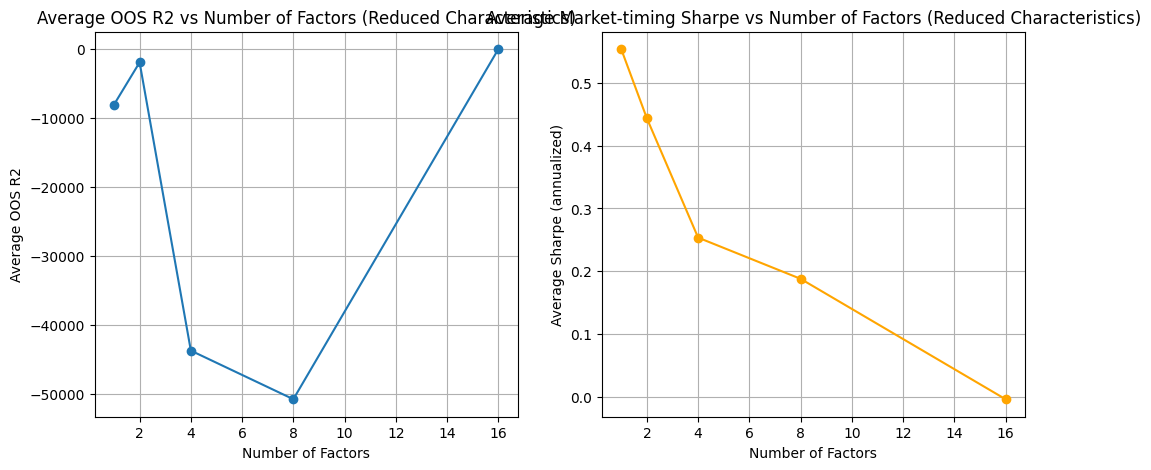

In [ ]:
# lets drop 1/3 of the char_feats_final as we get ipplosed problems now
char_feats_reduced = char_feats_final[-33:]
print(f"Number of characteristics used after reduction: {len(char_feats_reduced)}")
print("Characteristics used after reduction:", char_feats_reduced)
# run the IPCA_Grass_estimation with the reduced characteristics list, and see how the performance changes with the number of factors and the window length. We will try with 2,
# 4, 8, 16, 32 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
num_factors_list = [1, 2, 4, 8, 16]
num_iter = 30    
results_by_factor = {}
for num_fact in num_factors_list:
    # we iterate num_iter times for each num_fact to get an average performance
    all_results = []
    for i in range(num_iter):
        print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
        res = run_ipca_grass(
            df_trunc=df_trunc_extended,
            char_feats=char_feats_reduced,
            num_fact=num_fact,
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
    print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# Lets plot the results
num_factors = list(results_by_factor.keys())
avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(num_factors, avg_r2_oos_values, marker='o')
plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()



Num factors: 1, Run 1/30
OOS MSE: 3.787039e+00
OOS R2 : -6659.3603
Market-timing Sharpe (annualized): 0.145

Num factors: 1, Run 2/30
OOS MSE: 1.905960e+01
OOS R2 : -33519.5859
Market-timing Sharpe (annualized): 0.372

Num factors: 1, Run 3/30
OOS MSE: 6.369497e-01
OOS R2 : -1119.2192
Market-timing Sharpe (annualized): 1.153

Num factors: 1, Run 4/30
OOS MSE: 3.502775e+00
OOS R2 : -6159.4182
Market-timing Sharpe (annualized): 0.840

Num factors: 1, Run 5/30
OOS MSE: 1.392035e+02
OOS R2 : -244819.6566
Market-timing Sharpe (annualized): 0.249

Num factors: 1, Run 6/30
OOS MSE: 1.405416e+01
OOS R2 : -24716.4049
Market-timing Sharpe (annualized): 1.301

Num factors: 1, Run 7/30
OOS MSE: 3.682491e-01
OOS R2 : -646.6488
Market-timing Sharpe (annualized): 0.502

Num factors: 1, Run 8/30
OOS MSE: 1.743873e+00
OOS R2 : -3065.9930
Market-timing Sharpe (annualized): 0.657

Num factors: 1, Run 9/30
OOS MSE: 7.083813e-01
OOS R2 : -1244.8477
Market-timing Sharpe (annualized): 0.623

Num factors: 1,

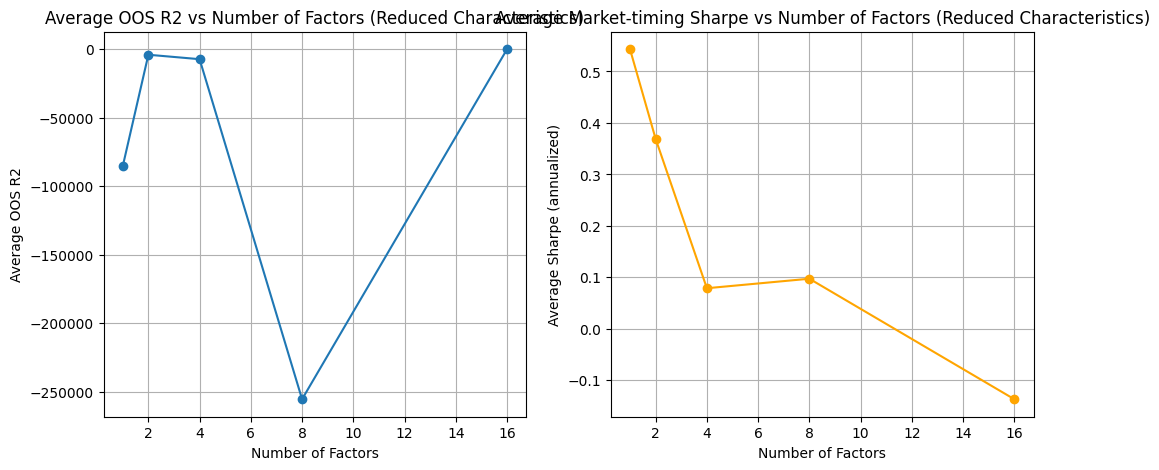

In [189]:
# Num iter 30 case for better confidence in the results, as there is some randomness in the IPCA estimation due to the optimization process, and we want to ensure that our results are not just a lucky run. We will try with 1, 2, 4, 8, 16 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
num_iter = 30    
results_by_factor = {}
for num_fact in num_factors_list:
    # we iterate num_iter times for each num_fact to get an average performance
    all_results = []
    for i in range(num_iter):
        print(f"\nNum factors: {num_fact}, Run {i+1}/{num_iter}")
        res = run_ipca_grass(
            df_trunc=df_trunc_extended,
            char_feats=char_feats_reduced,
            num_fact=num_fact,
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)
    avg_r2_oos = np.mean([res["r2_oos"] for res in all_results])
    avg_sharpe = np.mean([res["sharpe"] for res in all_results])
    results_by_factor[num_fact] = {"avg_r2_oos": avg_r2_oos, "avg_sharpe": avg_sharpe}
    print(f"\nNum factors: {num_fact}, Average OOS R2: {avg_r2_oos:.4f}, Average Sharpe: {avg_sharpe:.3f}")
# Lets plot the results
num_factors = list(results_by_factor.keys())
avg_r2_oos_values = [results_by_factor[nf]["avg_r2_oos"] for nf in num_factors]
avg_sharpe_values = [results_by_factor[nf]["avg_sharpe"] for nf in num_factors]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(num_factors, avg_r2_oos_values, marker='o')
plt.title("Average OOS R2 vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(num_factors, avg_sharpe_values, marker='o', color='orange')
plt.title("Average Market-timing Sharpe vs Number of Factors (Reduced Characteristics)")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()


### Things to clear up - when the sharpe seems to be so volatile, which return subspace structure do we examine to analyze the geometry

#### Things to note during run, char_feat can be high dimensinal but some chars can make the problem illposed, better to understand when and how this happens to avoid this during RFF runs

## ToDo
### Understand the code more -> Incorporate RFF code to the GrassManIPCA.py -> and the compare this 2020-2025 strategy on them both -> then test(same stock universe) for the entire History -> Increase the stock universe and test for entire history

In [191]:
#lets create rff transformations of the characteristics and then run the IPCA_Grass_estimation with the rff transformed characteristics, and see how the performance changes with the number of factors and the window length. 
from src.rff import RandomFourierFeatures
GAMMA = 0.2
N_FEATURES = 64

# RFF transform needs a dense numeric matrix
X_chars = df_trunc_extended[char_feats_reduced].copy()
date_level = "date" if "date" in X_chars.index.names else 1

# Impute missing values cross-sectionally by date, then columnwise fallback
X_chars = X_chars.groupby(level=date_level).transform(lambda s: s.fillna(s.median()))
X_chars = X_chars.fillna(X_chars.median()).fillna(0.0)

rff = RandomFourierFeatures(n_features=int(N_FEATURES / 2), gamma=GAMMA)
rff_data = rff.transform(X_chars, seed=1)

# Convert back to DataFrame so it can be used by run_ipca_grass
rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)

# Keep the same panel structure as before
df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])

# Run IPCA-Grassmann on RFF characteristics
num_iter_rff = 3
results_by_factor_rff = {}

for num_fact in num_factors_list:
    all_results = []
    for i in range(num_iter_rff):
        print(f"\n[RFF] Num factors: {num_fact}, Run {i+1}/{num_iter_rff}")
        res = run_ipca_grass(
            df_trunc=df_trunc_rff,
            char_feats=rff_cols,
            num_fact=num_fact,
            window_len=window_len,
            max_nan=0.3,
            max_zero=0.3,
            min_non_nan_frac=0.7,
        )
        all_results.append(res)

    results_by_factor_rff[num_fact] = {
        "avg_r2_oos": np.mean([res["r2_oos"] for res in all_results]),
        "avg_sharpe": np.mean([res["sharpe"] for res in all_results]),
    }

results_rff_df = pd.DataFrame(results_by_factor_rff).T
display(results_rff_df)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_rff_df.index, results_rff_df["avg_r2_oos"], marker="o")
plt.title("Average OOS R2 vs Number of Factors (RFF)")
plt.xlabel("Number of Factors")
plt.ylabel("Average OOS R2")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(results_rff_df.index, results_rff_df["avg_sharpe"], marker="o", color="orange")
plt.title("Average Market-timing Sharpe vs Number of Factors (RFF)")
plt.xlabel("Number of Factors")
plt.ylabel("Average Sharpe (annualized)")
plt.grid()

plt.tight_layout()
plt.show()


[RFF] Num factors: 1, Run 1/3
OOS MSE: 5.935776e+02
OOS R2 : -7849.0497
Market-timing Sharpe (annualized): 0.088

[RFF] Num factors: 1, Run 2/3
OOS MSE: 1.452540e+01
OOS R2 : -191.0981
Market-timing Sharpe (annualized): -0.463

[RFF] Num factors: 1, Run 3/3
OOS MSE: 4.165356e-01
OOS R2 : -4.5087
Market-timing Sharpe (annualized): 0.545

[RFF] Num factors: 2, Run 1/3
OOS MSE: 8.739072e-02
OOS R2 : -0.1557
Market-timing Sharpe (annualized): -0.454

[RFF] Num factors: 2, Run 2/3
OOS MSE: 9.676214e-02
OOS R2 : -0.2797
Market-timing Sharpe (annualized): -0.422

[RFF] Num factors: 2, Run 3/3
OOS MSE: 9.020767e-02
OOS R2 : -0.1930
Market-timing Sharpe (annualized): 0.436

[RFF] Num factors: 4, Run 1/3
OOS MSE: 7.792522e-02
OOS R2 : -0.0306
Market-timing Sharpe (annualized): 0.384

[RFF] Num factors: 4, Run 2/3
OOS MSE: 9.000276e-02
OOS R2 : -0.1903
Market-timing Sharpe (annualized): 0.193

[RFF] Num factors: 4, Run 3/3
OOS MSE: 7.975344e-02
OOS R2 : -0.0547
Market-timing Sharpe (annualized):

LinAlgError: Singular matrix

In [ ]:
# Lets run for num_features = 3, and N_FEATURES = 128 for the RFF transformation, and see how the performance changes with the number of factors and the window length. We will try with 1, 2, 4, 8, 16 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
GAMMA = 0.2
N_FEATURES_EFF = [16, 64, 256, 1024, 4096, 16384]
rff = RandomFourierFeatures(n_features=int(N_FEATURES / 2), gamma=GAMMA)
rff_data = rff.transform(X_chars, seed=1)
rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns =rff_cols)
df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])
num_iter_rff = 5
results_by_factor_rff = {} 
#lets runf or different N_FEATURES_EFF values and store the results in a dictionary, and then we will plot the results to see how the performance changes with the number of features in the RFF transformation. We will try with 1, 2, 4, 8, 16 factors and see how the performance changes. We will use the same window length of 24 months for all runs.
for n_feat in N_FEATURES_EFF:
    rff = RandomFourierFeatures(n_features=int(n_feat / 2), gamma=GAMMA)
    rff_data = rff.transform(X_chars, seed=1)
    rff_cols = [f"rff_{i+1}" for i in range(rff_data.shape[1])]
    rff_df = pd.DataFrame(rff_data, index=df_trunc_extended.index, columns=rff_cols)
    df_trunc_rff = pd.concat([df_trunc_extended[["Price", "ret"]], rff_df], axis=1).dropna(subset=["ret"])

    results_by_factor_rff_nfeat = {}
    for num_fact in num_factors_list:
        all_results = []
        for i in range(num_iter_rff):
            print(f"\n[RFF] N_FEATURES: {n_feat}, Num factors: {num_fact}, Run {i+1}/{num_iter_rff}")
            res = run_ipca_grass(
                df_trunc=df_trunc_rff,
                char_feats=rff_cols,
                num_fact=num_fact,
                window_len=window_len,
                max_nan=0.3,
                max_zero=0.3,
                min_non_nan_frac=0.7,
            )
            all_results.append(res)

        results_by_factor_rff_nfeat[num_fact] = {
            "avg_r2_oos": np.mean([res["r2_oos"] for res in all_results]),
            "avg_sharpe": np.mean([res["sharpe"] for res in all_results]),
        }
    results_by_factor_rff[n_feat] = results_by_factor_rff_nfeat
# Lets plot the results for different N_FEATURES_EFF values
plt.figure(figsize=(18, 12))
for i, n_feat in enumerate(N_FEATURES_EFF):
    results_rff_nfeat_df = pd.DataFrame(results_by_factor_rff[n_feat]).T
    plt.subplot(3, 2, i + 1)
    plt.plot(results_rff_nfeat_df.index, results_rff_nfeat_df["avg_r2_oos"], marker="o")
    plt.title(f"Average OOS R2 vs Number of Factors (RFF, N_FEATURES={n_feat})")
    plt.xlabel("Number of Factors")
    plt.ylabel("Average OOS R2")
    plt.grid()
plt.tight_layout()
plt.show()




[RFF] N_FEATURES: 16, Num factors: 1, Run 1/5
OOS MSE: 1.118511e-01
OOS R2 : -0.4792
Market-timing Sharpe (annualized): 0.228

[RFF] N_FEATURES: 16, Num factors: 1, Run 2/5
OOS MSE: 1.864595e-01
OOS R2 : -1.4659
Market-timing Sharpe (annualized): 0.393

[RFF] N_FEATURES: 16, Num factors: 1, Run 3/5
OOS MSE: 1.130419e+00
OOS R2 : -13.9498
Market-timing Sharpe (annualized): 0.275

[RFF] N_FEATURES: 16, Num factors: 1, Run 4/5
OOS MSE: 6.537970e-01
OOS R2 : -7.6465
Market-timing Sharpe (annualized): 0.574

[RFF] N_FEATURES: 16, Num factors: 1, Run 5/5
OOS MSE: 3.691785e-01
OOS R2 : -3.8824
Market-timing Sharpe (annualized): 0.428

[RFF] N_FEATURES: 16, Num factors: 2, Run 1/5
OOS MSE: 8.975418e-02
OOS R2 : -0.1870
Market-timing Sharpe (annualized): 0.470

[RFF] N_FEATURES: 16, Num factors: 2, Run 2/5
OOS MSE: 9.846025e-02
OOS R2 : -0.3021
Market-timing Sharpe (annualized): 0.577

[RFF] N_FEATURES: 16, Num factors: 2, Run 3/5
